In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
#Cargar el dataset

train = pd.read_csv('Archivos_Naive_Bayes/train_embeddings_balanced_AUG_GPT4o_mini_total_augmented_text-embedding-3-large.csv')
test = pd.read_csv('test_embeddings_text-embedding-3-large.csv')    


In [3]:
feature_cols = [c for c in train.columns if c != 'label']

X_train = train[feature_cols].values
y_train = train['label'].values

X_test = test[feature_cols].values
y_test = test['label'].values

In [4]:
# Entrenar el segundo modelo Random Forest (aumentado)

train_rf_aug = pd.read_csv("Archivos_Random_Forest_1/train_embeddings_total_augmented_data_text-embedding-3-large.csv")
X_train_rf_aug = train_rf_aug[feature_cols].values
y_train_rf_aug = train_rf_aug["label"].values

rf_aug = RandomForestClassifier(
    max_depth=None,
    min_samples_leaf=1,
    n_estimators=200,
    random_state=42,
    n_jobs=1,
)
rf_aug.fit(X_train_rf_aug, y_train_rf_aug)

RandomForestClassifier(n_estimators=200, n_jobs=1, random_state=42)

In [5]:
# Evaluar el segundo modelo Random Forest (aumentado)

y_pred_rf_aug = rf_aug.predict(X_test)
y_prob_rf_aug = rf_aug.predict_proba(X_test)[:, 1]

In [6]:
# Imprimir metricas

print(classification_report(y_test, y_pred_rf_aug, digits=5))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_aug))

              precision    recall  f1-score   support

           0    0.99755   0.83745   0.91051       972
           1    0.14595   0.93103   0.25234        29

    accuracy                        0.84016      1001
   macro avg    0.57175   0.88424   0.58143      1001
weighted avg    0.97288   0.84016   0.89145      1001

Confusion Matrix:
[[814 158]
 [  2  27]]


In [7]:
train_rf = pd.read_csv('Archivos_Random_Forest/train_embeddings_balanced_total_sentence_prompt_GPT4o_mini_text-embedding-3-large.csv')
X_train_rf = train_rf[feature_cols].values
y_train_rf = train_rf['label'].values

In [8]:
random_forest = RandomForestClassifier(
    max_depth=None,
    min_samples_leaf=1,
    n_estimators=200,
    random_state=42,
    n_jobs=1
    )

In [9]:
random_forest.fit(X_train_rf, y_train_rf) 

y_pred_rf = random_forest.predict(X_test)
y_prob_rf  = random_forest.predict_proba(X_test)[:, 1]

In [10]:
print(classification_report(y_test, y_pred_rf, digits=5))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0    0.98574   0.99588   0.99079       972
           1    0.78947   0.51724   0.62500        29

    accuracy                        0.98202      1001
   macro avg    0.88761   0.75656   0.80789      1001
weighted avg    0.98006   0.98202   0.98019      1001

Confusion Matrix:
[[968   4]
 [ 14  15]]


In [11]:
train_lr = pd.read_csv("Archivos_Logistic_Regression/train_embeddings_balanced_total_sinonimos_text-embedding-3-large.csv")
X_train_lr = train_lr[feature_cols].values
y_train_lr = train_lr['label'].values

In [12]:
model_lr = LogisticRegression(
    C = 100,
    penalty = 'l2',
    solver='saga',
    max_iter=1000
)

In [13]:
model_lr.fit(X_train_lr, y_train_lr)

LogisticRegression(C=100, max_iter=1000, solver='saga')

In [14]:
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

In [15]:
print(classification_report(y_test, y_pred_lr, digits=5))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0    0.99276   0.98765   0.99020       972
           1    0.64706   0.75862   0.69841        29

    accuracy                        0.98102      1001
   macro avg    0.81991   0.87314   0.84431      1001
weighted avg    0.98275   0.98102   0.98175      1001

Confusion Matrix:
[[960  12]
 [  7  22]]


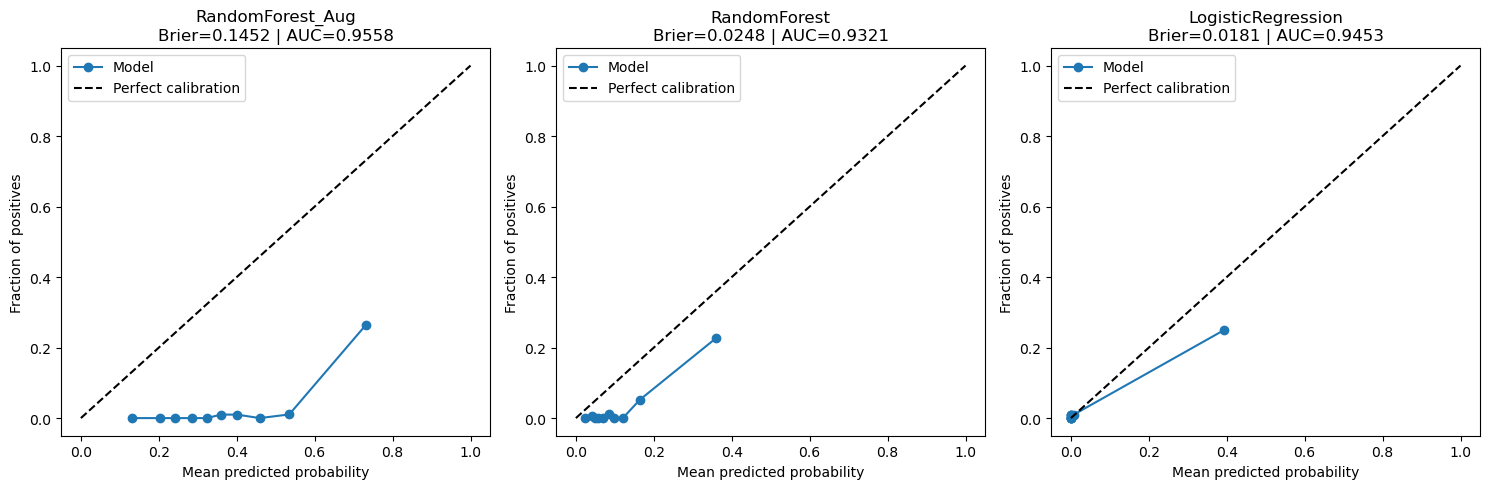

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

models_probs = {
    "RandomForest_Aug":    y_prob_rf_aug,
    "RandomForest":        y_prob_rf,
    "LogisticRegression":  y_prob_lr,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, y_prob) in zip(axes, models_probs.items()):
    # Curva de calibracion
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='quantile')
    ax.plot(prob_pred, prob_true, marker='o', label='Model')
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

    brier = brier_score_loss(y_test, y_prob)
    auc   = roc_auc_score(y_test, y_prob)

    ax.set_title(f"{name}\nBrier={brier:.4f} | AUC={auc:.4f}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend()

plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV

# --- Split a calibration set from test (or use a separate val set if you have one) ---
# IMPORTANT: ideally use a dedicated calibration set, not the same test set
# If your test set is your only held-out data, use a portion of it
idx_cal, idx_eval = train_test_split(
    np.arange(len(y_test)), test_size=0.5, random_state=42, stratify=y_test
)
X_cal, X_eval = X_test[idx_cal], X_test[idx_eval]
y_cal, y_eval = y_test[idx_cal], y_test[idx_eval]

# --- Calibrate second RandomForest / augmented model (isotonic) ---
cal_rf_aug = CalibratedClassifierCV(rf_aug, method='isotonic', cv='prefit')
cal_rf_aug.fit(X_cal, y_cal)
y_prob_rf_aug_cal = cal_rf_aug.predict_proba(X_eval)[:, 1]

# --- Calibrate RandomForest (isotonic) ---
cal_rf = CalibratedClassifierCV(random_forest, method='isotonic', cv='prefit')
cal_rf.fit(X_cal, y_cal)
y_prob_rf_cal = cal_rf.predict_proba(X_eval)[:, 1]

# --- Calibrate LogisticRegression (Platt/sigmoid is sufficient) ---
cal_lr = CalibratedClassifierCV(model_lr, method='sigmoid', cv='prefit')
cal_lr.fit(X_cal, y_cal)
y_prob_lr_cal = cal_lr.predict_proba(X_eval)[:, 1]

# --- Compare Brier scores before/after ---
for name, raw, cal in [
    ("RandomForest_Aug",   y_prob_rf_aug[idx_eval],  y_prob_rf_aug_cal),
    ("RandomForest",       y_prob_rf[idx_eval],      y_prob_rf_cal),
    ("LogisticRegression", y_prob_lr[idx_eval],      y_prob_lr_cal),
]:
    b_raw = brier_score_loss(y_eval, raw)
    b_cal = brier_score_loss(y_eval, cal)
    print(f"{name:20s}  Brier raw={b_raw:.4f}  calibrated={b_cal:.4f}  delta={b_raw-b_cal:+.4f}")

RandomForest_Aug      Brier raw=0.1419  calibrated=0.0206  delta=+0.1214
RandomForest          Brier raw=0.0275  calibrated=0.0228  delta=+0.0047
LogisticRegression    Brier raw=0.0195  calibrated=0.0176  delta=+0.0020


In [18]:
# After calibration, the r_q values for the risk index are:
""" r_q_rf_aug = cal_rf_aug.predict_proba(X_new)[:, 1]   # RandomForest aumentado calibrated
r_q_rf = cal_rf.predict_proba(X_new)[:, 1]       # RandomForest calibrated
r_q_lr = cal_lr.predict_proba(X_new)[:, 1]       # LogisticRegression calibrated

# All values are in [0, 1] - verified by:
assert r_q_rf_aug.min() >= 0 and r_q_rf_aug.max() <= 1
assert r_q_rf.min() >= 0 and r_q_rf.max() <= 1
assert r_q_lr.min() >= 0 and r_q_lr.max() <= 1 """

' r_q_rf_aug = cal_rf_aug.predict_proba(X_new)[:, 1]   # RandomForest aumentado calibrated\nr_q_rf = cal_rf.predict_proba(X_new)[:, 1]       # RandomForest calibrated\nr_q_lr = cal_lr.predict_proba(X_new)[:, 1]       # LogisticRegression calibrated\n\n# All values are in [0, 1] - verified by:\nassert r_q_rf_aug.min() >= 0 and r_q_rf_aug.max() <= 1\nassert r_q_rf.min() >= 0 and r_q_rf.max() <= 1\nassert r_q_lr.min() >= 0 and r_q_lr.max() <= 1 '

In [ ]:
# Cargar datos igual que X_test
# new_data = pd.read_csv('your_new_data.csv')
# X_new = new_data[feature_cols].values   # same feature_cols as training

# r_q_rf_aug = cal_rf_aug.predict_proba(X_new)[:, 1]
# r_q_rf = cal_rf.predict_proba(X_new)[:, 1]
# r_q_lr = cal_lr.predict_proba(X_new)[:, 1]

In [20]:
print(X_test.shape)

(1001, 3072)


## IC (Media aritmetica) sin `contract_id`: preguntas por proceso especifico

Caso 1: cuando se tiene **solo las preguntas de un proceso**, el indice es la media de sus `r_q`.
Caso 2: para simulacion, se crean pseudo-procesos agrupando preguntas del test en tamaÃƒÂ±os 2-15.


In [21]:
import numpy as np
import pandas as pd

def ic_media_aritmetica_proceso(scores):
    """
    IC para UN proceso (sin id):
        IC = mean(r_q)
    donde `scores` es una lista/array de preguntas del mismo proceso.
    """
    arr = np.asarray(scores, dtype=float)
    arr = arr[~np.isnan(arr)]
    if arr.size == 0:
        raise ValueError('No hay scores validos para calcular IC del proceso.')
    if (arr < 0).any() or (arr > 1).any():
        raise ValueError('Todos los scores deben estar en [0,1].')
    return float(arr.mean())

def agrupar_en_pseudoprocesos(n_rows, min_size=2, max_size=15, seed=42):
    """
    Genera ids de pseudo-proceso para n_rows preguntas, con tamaÃƒÂ±os aleatorios en [min_size, max_size].
    El ultimo grupo tambien queda en [2,15] (ajustando con el penultimo si hace falta).
    """
    if min_size < 2 or max_size < min_size:
        raise ValueError('Rango de tama?o inv?lido.')

    rng = np.random.default_rng(seed)
    sizes = []
    remaining = n_rows

    while remaining > 0:
        if remaining < min_size:
            if not sizes:
                sizes = [remaining]
            else:
                sizes[-1] += remaining
            break

        if remaining <= max_size:
            sizes.append(remaining)
            break

        s = int(rng.integers(min_size, max_size + 1))
        if remaining - s == 1:
            s += 1
        sizes.append(s)
        remaining -= s

    # Si algun grupo excede max_size por ajuste final, redistribuir de forma simple
    i = 0
    while i < len(sizes):
        if sizes[i] > max_size:
            overflow = sizes[i] - max_size
            sizes[i] = max_size
            sizes.insert(i + 1, overflow)
        i += 1

    # Construir ids
    ids = []
    for p, s in enumerate(sizes, start=1):
        ids.extend([f'P{p:04d}'] * s)

    if len(ids) != n_rows:
        raise RuntimeError('Error interno al construir pseudo-procesos.')

    return ids, sizes


In [ ]:
# === Simulaci?n solicitada sobre test_embeddings_text-embedding-3-large.csv ===
# Se agrupan las preguntas en pseudo-procesos de tama?o 2-15

# 1) Base de preguntas (ya cargada en variable `test` en este notebook)
df_questions = test.copy().reset_index(drop=True)

# 2) Score por pregunta (r_q)
# Usa probabilidad del modelo si existe; si no, usa label binaria como fallback
if 'y_prob_lr' in globals() and len(y_prob_lr) == len(df_questions):
    df_questions['r_q'] = y_prob_lr
elif 'y_prob_rf' in globals() and len(y_prob_rf) == len(df_questions):
    df_questions['r_q'] = y_prob_rf
elif 'y_prob_rf_aug' in globals() and len(y_prob_rf_aug) == len(df_questions):
    df_questions['r_q'] = y_prob_rf_aug
else:
    # fallback binario (sigue siendo v?lido para media aritm?tica)
    df_questions['r_q'] = df_questions['label'].astype(float)

# 3) Crear pseudo-procesos tama?o 2..15
process_ids, process_sizes = agrupar_en_pseudoprocesos(
    n_rows=len(df_questions), min_size=2, max_size=15, seed=42
)
df_questions['process_id'] = process_ids

# 4) IC por pseudo-proceso (media aritm?tica)
ic_por_proceso = (
    df_questions.groupby('process_id', as_index=False)
    .agg(
        IC_media=('r_q', 'mean'),
        n_preguntas=('r_q', 'size')
    )
    .sort_values('IC_media', ascending=False)
    .reset_index(drop=True)
)

# 5) Verificaciones
assert ic_por_proceso['n_preguntas'].between(2, 15).all(), 'Hay grupos fuera de 2..15'
assert ic_por_proceso['IC_media'].between(0, 1).all(), 'IC fuera de [0,1]'

print('Preguntas totales:', len(df_questions))
print('Pseudo-procesos creados:', ic_por_proceso.shape[0])
print('TamaÃƒÂ±o minimo/maximo:', ic_por_proceso['n_preguntas'].min(), '/', ic_por_proceso['n_preguntas'].max())
display(ic_por_proceso.head(15))


In [23]:
# === Ejemplo: proceso especifico (sin process_id) ===
# Toma cualquier pseudo-proceso y calcula su IC directamente desde sus preguntas
ejemplo_pid = ic_por_proceso.loc[0, 'process_id']
scores_ejemplo = df_questions.loc[df_questions['process_id'] == ejemplo_pid, 'r_q'].to_numpy()
IC_ejemplo = ic_media_aritmetica_proceso(scores_ejemplo)
print(f'Proceso {ejemplo_pid} | n={scores_ejemplo.size} | IC_media={IC_ejemplo:.6f}')


Proceso P0033 | n=3 | IC_media=0.332880


In [ ]:
# Reuse pseudo-process grouping
process_ids, _ = agrupar_en_pseudoprocesos(len(df_questions), min_size=2, max_size=15, seed=42)
df_questions["process_id"] = process_ids

# Attach model probabilities
df_questions["r_q_lr"] = y_prob_lr
df_questions["r_q_rf"] = y_prob_rf
df_questions["r_q_rf_aug"] = y_prob_rf_aug

# IC per pseudo-process for each model (arithmetic mean)
ic_3modelos = (
    df_questions.groupby("process_id", as_index=False)
    .agg(
        n_preguntas=("process_id", "size"),
        IC_lr=("r_q_lr", "mean"),
        IC_rf=("r_q_rf", "mean"),
        IC_rf_aug=("r_q_rf_aug", "mean"),
    )
)

# Optional checks
for c in ["IC_lr", "IC_rf", "IC_rf_aug"]:
    assert ic_3modelos[c].between(0, 1).all(), f"{c} out of [0,1]"

print(ic_3modelos.head(15))

In [20]:
# 1) Base questions + pseudo-processes
df_questions = pd.read_csv("test_embeddings_text-embedding-3-large.csv").reset_index(drop=True)
process_ids, _ = agrupar_en_pseudoprocesos(len(df_questions), min_size=2, max_size=15, seed=42)
df_questions["process_id"] = process_ids

# 2) Per-question probabilities from each model
df_questions["r_q_lr"] = y_prob_lr
df_questions["r_q_rf"] = y_prob_rf
df_questions["r_q_rf_aug"] = y_prob_rf_aug

# 3) IC per process per model (arithmetic mean)
ic = (
    df_questions.groupby("process_id", as_index=False)
    .agg(
        n_preguntas=("process_id", "size"),
        IC_lr=("r_q_lr", "mean"),
        IC_rf=("r_q_rf", "mean"),
        IC_rf_aug=("r_q_rf_aug", "mean"),
    )
)

# 4) Fused mean across models, weighted by inverse Brier score
brier_lr = brier_score_loss(y_test, y_prob_lr)
brier_rf = brier_score_loss(y_test, y_prob_rf)
brier_rf_aug = brier_score_loss(y_test, y_prob_rf_aug)

scores = np.array([
    1 / (brier_lr + 1e-9),
    1 / (brier_rf + 1e-9),
    1 / (brier_rf_aug + 1e-9),
], dtype=float)
w_lr, w_rf, w_rf_aug = scores / scores.sum()

ic["IC_fusion"] = (
    w_lr * ic["IC_lr"] +
    w_rf * ic["IC_rf"] +
    w_rf_aug * ic["IC_rf_aug"]
)

# 5) Validations
for col in ["IC_lr", "IC_rf", "IC_rf_aug", "IC_fusion"]:
    assert ic[col].between(0, 1).all(), f"{col} out of [0,1]"

# 6) Ranking by fused index
ic = ic.sort_values("IC_fusion", ascending=False).reset_index(drop=True)
print("Weights:", {"lr": w_lr, "rf": w_rf, "rf_aug": w_rf_aug})
print(ic.head(10))

NameError: name 'agrupar_en_pseudoprocesos' is not defined

In [19]:
import numpy as np

# Brier scores for the current model set
brier_lr = brier_score_loss(y_test, y_prob_lr)
brier_rf = brier_score_loss(y_test, y_prob_rf)
brier_rf_aug = brier_score_loss(y_test, y_prob_rf_aug)
eps = 1e-9

scores = np.array([
    1/(brier_lr + eps),
    1/(brier_rf + eps),
    1/(brier_rf_aug + eps)
], dtype=float)

w_lr, w_rf, w_rf_aug = scores / scores.sum()
print(w_lr, w_rf, w_rf_aug)

0.5396634432766038 0.39320065479403 0.06713590192936626


## IC - Metodo Maximo Contractual

Definicion (tesis): `IC = max(r_q)` por proceso/contrato.
Idea: si hay una pregunta con riesgo muy alto, todo el proceso se prioriza alto.


In [27]:
import numpy as np
import pandas as pd

def ic_maximo_proceso(scores):
    """
    IC para un proceso espec?fico (sin contract_id):
        IC = max(r_q)
    """
    arr = np.asarray(scores, dtype=float)
    arr = arr[~np.isnan(arr)]
    if arr.size == 0:
        raise ValueError('No hay scores v?lidos para calcular IC m?ximo.')
    if (arr < 0).any() or (arr > 1).any():
        raise ValueError('Todos los scores deben estar en [0,1].')
    return float(arr.max())


In [ ]:
# Simulacion en test_embeddings_text-embedding-3-large.csv
# Grupos pseudo-proceso de tamaÃƒÂ±o 2..15 y calculo de IC maximo

df_questions_max = pd.read_csv('test_embeddings_text-embedding-3-large.csv').reset_index(drop=True)

# score por pregunta
if 'y_prob_lr' in globals() and len(y_prob_lr) == len(df_questions_max):
    df_questions_max['r_q'] = y_prob_lr
elif 'y_prob_rf' in globals() and len(y_prob_rf) == len(df_questions_max):
    df_questions_max['r_q'] = y_prob_rf
elif 'y_prob_rf_aug' in globals() and len(y_prob_rf_aug) == len(df_questions_max):
    df_questions_max['r_q'] = y_prob_rf_aug
else:
    df_questions_max['r_q'] = df_questions_max['label'].astype(float)

process_ids_max, _ = agrupar_en_pseudoprocesos(
    n_rows=len(df_questions_max), min_size=2, max_size=15, seed=42
)
df_questions_max['process_id'] = process_ids_max

ic_max_por_proceso = (
    df_questions_max.groupby('process_id', as_index=False)
    .agg(
        IC_max=('r_q', 'max'),
        n_preguntas=('r_q', 'size')
    )
    .sort_values('IC_max', ascending=False)
    .reset_index(drop=True)
)

assert ic_max_por_proceso['n_preguntas'].between(2, 15).all(), 'Hay grupos fuera de 2..15'
assert ic_max_por_proceso['IC_max'].between(0, 1).all(), 'IC_max fuera de [0,1]'

print('Pseudo-procesos:', ic_max_por_proceso.shape[0])
print('TamaÃƒÂ±o min/max:', ic_max_por_proceso['n_preguntas'].min(), '/', ic_max_por_proceso['n_preguntas'].max())
display(ic_max_por_proceso.head(10))


In [29]:
# Ejemplo: proceso especifico (sin process_id en la funcion)
pid = ic_max_por_proceso.loc[0, 'process_id']
scores_pid = df_questions_max.loc[df_questions_max['process_id'] == pid, 'r_q'].to_numpy()
ic_pid = ic_maximo_proceso(scores_pid)
print(f'Proceso {pid} | n={scores_pid.size} | IC_max={ic_pid:.6f}')


Proceso P0014 | n=12 | IC_max=0.999982


## IC - Metodo Top-K average

In [30]:
def ic_topk_proceso(scores, k=3):
    """
    IC Top-k:
        IC = mean(top-k(r_q))
    If n < k, uses k_eff = n.
    """
    arr = np.asarray(scores, dtype=float)
    arr = arr[~np.isnan(arr)]
    if arr.size == 0:
        raise ValueError("No valid scores to compute IC top-k.")
    if k < 1:
        raise ValueError("k must be >= 1.")
    if (arr < 0).any() or (arr > 1).any():
        raise ValueError("Scores must be in [0,1].")

    k_eff = min(int(k), arr.size)
    topk = np.partition(arr, arr.size - k_eff)[-k_eff:]
    return float(topk.mean())

In [31]:
def agrupar_en_pseudoprocesos(n_rows, min_size=2, max_size=15, seed=42):
    if min_size < 2 or max_size < min_size:
        raise ValueError("Invalid size range.")

    rng = np.random.default_rng(seed)
    sizes = []
    remaining = n_rows

    while remaining > 0:
        if remaining < min_size:
            if not sizes:
                sizes = [remaining]
            else:
                sizes[-1] += remaining
            break

        if remaining <= max_size:
            sizes.append(remaining)
            break

        s = int(rng.integers(min_size, max_size + 1))
        if remaining - s == 1:  # avoid ending with group of 1
            s += 1
        sizes.append(s)
        remaining -= s

    i = 0
    while i < len(sizes):
        if sizes[i] > max_size:
            overflow = sizes[i] - max_size
            sizes[i] = max_size
            sizes.insert(i + 1, overflow)
        i += 1

    ids = []
    for p, s in enumerate(sizes, start=1):
        ids.extend([f"P{p:04d}"] * s)

    if len(ids) != n_rows:
        raise RuntimeError("Internal grouping error.")
    return ids, sizes

In [ ]:
k_top = 3  # change if needed

df_topk = pd.read_csv("test_embeddings_text-embedding-3-large.csv").reset_index(drop=True)
n = len(df_topk)

# Requires these arrays to exist in memory
# (from your previous notebook cells)
for var_name in ["y_prob_lr", "y_prob_rf", "y_prob_rf_aug"]:
    if var_name not in globals():
        raise ValueError(f"Missing {var_name}. Run prediction cells first.")
    if len(globals()[var_name]) != n:
        raise ValueError(f"Length mismatch in {var_name}: {len(globals()[var_name])} vs {n}")

df_topk["r_q_lr"] = np.asarray(y_prob_lr, dtype=float)
df_topk["r_q_rf"] = np.asarray(y_prob_rf, dtype=float)
df_topk["r_q_rf_aug"] = np.asarray(y_prob_rf_aug, dtype=float)

In [ ]:
w_lr, w_rf, w_rf_aug = 1/3, 1/3, 1/3  # edit if desired
w = np.array([w_lr, w_rf, w_rf_aug], dtype=float)
if (w < 0).any() or not np.isclose(w.sum(), 1.0):
    raise ValueError("Invalid weights: must be >=0 and sum to 1.")

df_topk["r_q_fusion"] = (
    w_lr * df_topk["r_q_lr"] +
    w_rf * df_topk["r_q_rf"] +
    w_rf_aug * df_topk["r_q_rf_aug"]
)

In [34]:
process_ids, _ = agrupar_en_pseudoprocesos(n_rows=n, min_size=2, max_size=15, seed=42)
df_topk["process_id"] = process_ids

def _topk_mean_series(s, k):
    a = s.to_numpy(dtype=float)
    k_eff = min(int(k), a.size)
    return np.partition(a, a.size - k_eff)[-k_eff:].mean()

In [ ]:
ic_topk_all = (
    df_topk.groupby("process_id", as_index=False)
    .agg(
        n_preguntas=("process_id", "size"),
        IC_topk_lr=("r_q_lr", lambda s: _topk_mean_series(s, k_top)),
        IC_topk_rf=("r_q_rf", lambda s: _topk_mean_series(s, k_top)),
        IC_topk_rf_aug=("r_q_rf_aug", lambda s: _topk_mean_series(s, k_top)),
        IC_topk_fusion=("r_q_fusion", lambda s: _topk_mean_series(s, k_top)),
    )
    .sort_values("IC_topk_fusion", ascending=False)
    .reset_index(drop=True)
)

In [ ]:
assert ic_topk_all["n_preguntas"].between(2, 15).all(), "Group size out of [2,15]"
for c in ["IC_topk_lr", "IC_topk_rf", "IC_topk_rf_aug", "IC_topk_fusion"]:
    assert ic_topk_all[c].between(0, 1).all(), f"{c} out of [0,1]"

print(f"k_top = {k_top}")
print(ic_topk_all.head(15))

In [37]:
pid = ic_topk_all.loc[0, "process_id"]
scores_pid = df_topk.loc[df_topk["process_id"] == pid, "r_q_fusion"].to_numpy()
ic_pid_topk = ic_topk_proceso(scores_pid, k=k_top)
print(f"Process {pid} | n={scores_pid.size} | IC_topk_fusion={ic_pid_topk:.6f}")

Process P0026 | n=11 | IC_topk_fusion=0.783715


## High Percentile for ONE process

In [38]:
def ic_percentil_alto_proceso(scores, alpha=0.90):
      """
      IC high percentile:
          IC = Percentil_alpha(r_q)
      alpha in [0,1], e.g. 0.90, 0.95.
      """
      arr = np.asarray(scores, dtype=float)
      arr = arr[~np.isnan(arr)]
      if arr.size == 0:
          raise ValueError("No valid scores to compute high percentile IC.")
      if not (0 <= alpha <= 1):
          raise ValueError("alpha must be in [0,1].")
      if (arr < 0).any() or (arr > 1).any():
          raise ValueError("Scores must be in [0,1].")
      return float(np.quantile(arr, alpha))

In [39]:
def agrupar_en_pseudoprocesos(n_rows, min_size=2, max_size=15, seed=42):
    if min_size < 2 or max_size < min_size:
        raise ValueError("Invalid size range.")

    rng = np.random.default_rng(seed)
    sizes = []
    remaining = n_rows

    while remaining > 0:
        if remaining < min_size:
            if not sizes:
                sizes = [remaining]
            else:
                sizes[-1] += remaining
            break

        if remaining <= max_size:
            sizes.append(remaining)
            break

        s = int(rng.integers(min_size, max_size + 1))
        if remaining - s == 1:
            s += 1
        sizes.append(s)
        remaining -= s

    i = 0
    while i < len(sizes):
        if sizes[i] > max_size:
            overflow = sizes[i] - max_size
            sizes[i] = max_size
            sizes.insert(i + 1, overflow)
        i += 1

    ids = []
    for p, s in enumerate(sizes, start=1):
        ids.extend([f"P{p:04d}"] * s)

    if len(ids) != n_rows:
        raise RuntimeError("Internal grouping error.")
    return ids, sizes

In [40]:
alpha = 0.90  # high percentile (change to 0.95, 0.80, etc.)

df_pct = pd.read_csv("test_embeddings_text-embedding-3-large.csv").reset_index(drop=True)
n = len(df_pct)

In [ ]:
for var_name in ["y_prob_lr", "y_prob_rf", "y_prob_rf_aug"]:
    if var_name not in globals():
        raise ValueError(f"Missing {var_name}. Run prediction cells first.")
    if len(globals()[var_name]) != n:
        raise ValueError(f"Length mismatch in {var_name}: {len(globals()[var_name])} vs {n}")

df_pct["r_q_lr"] = np.asarray(y_prob_lr, dtype=float)
df_pct["r_q_rf"] = np.asarray(y_prob_rf, dtype=float)
df_pct["r_q_rf_aug"] = np.asarray(y_prob_rf_aug, dtype=float)

In [ ]:
w_lr, w_rf, w_rf_aug = 1/3, 1/3, 1/3
w = np.array([w_lr, w_rf, w_rf_aug], dtype=float)
if (w < 0).any() or not np.isclose(w.sum(), 1.0):
    raise ValueError("Invalid weights: must be >=0 and sum to 1.")

df_pct["r_q_fusion"] = (
    w_lr * df_pct["r_q_lr"] +
    w_rf * df_pct["r_q_rf"] +
    w_rf_aug * df_pct["r_q_rf_aug"]
)

In [ ]:
process_ids, _ = agrupar_en_pseudoprocesos(n_rows=n, min_size=2, max_size=15, seed=42)
df_pct["process_id"] = process_ids

def _q_series(s, a):
    return float(np.quantile(s.to_numpy(dtype=float), a))

# Compute percentile IC per process
ic_pct_all = (
    df_pct.groupby("process_id", as_index=False)
    .agg(
        n_preguntas=("process_id", "size"),
        IC_pctl_lr=("r_q_lr", lambda s: _q_series(s, alpha)),
        IC_pctl_rf=("r_q_rf", lambda s: _q_series(s, alpha)),
        IC_pctl_rf_aug=("r_q_rf_aug", lambda s: _q_series(s, alpha)),
        IC_pctl_fusion=("r_q_fusion", lambda s: _q_series(s, alpha)),
    )
    .sort_values("IC_pctl_fusion", ascending=False)
    .reset_index(drop=True)
)

In [ ]:
assert ic_pct_all["n_preguntas"].between(2, 15).all(), "Group size out of [2,15]"
for c in ["IC_pctl_lr", "IC_pctl_rf", "IC_pctl_rf_aug", "IC_pctl_fusion"]:
    assert ic_pct_all[c].between(0, 1).all(), f"{c} out of [0,1]"

print(f"alpha = {alpha}")
print(ic_pct_all.head(15))


In [45]:

# Example: one specific process only
pid = ic_pct_all.loc[0, "process_id"]
scores_pid = df_pct.loc[df_pct["process_id"] == pid, "r_q_fusion"].to_numpy()
ic_pid_pct = ic_percentil_alto_proceso(scores_pid, alpha=alpha)
print(f"Process {pid} | n={scores_pid.size} | IC_pctl_fusion={ic_pid_pct:.6f}")

Process P0008 | n=11 | IC_pctl_fusion=0.819705


###SEPARACION